In [1]:
import json
import pickle
from pathlib import Path
from collections import Counter

import pandas as pd
from tqdm.notebook import tqdm

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [2]:
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to /Users/lasse/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/lasse/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
INPUT_FILE = "995,000_rows.csv"
OUTPUT_DIR = Path("processed_chunks_paquet")
OUTPUT_DIR.mkdir(exist_ok=True)

CHUNK_SIZE = 10000
TEXT_COL = "content"
LABEL_COL = "type"
DOMAIN_COL = "domain"
URL_COL = "url"
DATE_COL = "scraped_at"

In [4]:
stop_words = set(stopwords.words("english"))
stemmer = PorterStemmer()

def tokenize_text(text):
    text = str(text).lower()
    return word_tokenize(text)

def clean_tokens(tokens):
    # Keep alphabetic tokens only, remove stopwords
    return [t for t in tokens if t.isalpha() and t not in stop_words]

def stem_tokens(tokens):
    return [stemmer.stem(t) for t in tokens]

In [5]:
stats = {
    "n_rows": 0,
    "n_missing_content": 0,
    "total_tokens_before": 0,
    "total_tokens_after_stopwords": 0,
    "unique_tokens_before": set(),
    "unique_tokens_after_stopwords": set(),
    "unique_tokens_after_stemming": set(),
    "top_words_before": Counter(),
    "top_words_after_stopwords": Counter(),
    "top_words_after_stemming": Counter(),
}

In [6]:
chunk_files = []
seen_urls = set()

reader = pd.read_csv(INPUT_FILE, chunksize=CHUNK_SIZE)

for i, chunk in enumerate(tqdm(reader, desc="Processing chunks", total=995000//10000)):
    # Remove duplicate URLs seen in previous chunks
    if "url" in chunk.columns:
        before = len(chunk)
        chunk = chunk[~chunk["url"].isin(seen_urls)]
        chunk = chunk.drop_duplicates(subset="url")
        seen_urls.update(chunk["url"].dropna().tolist())
        stats["n_duplicate_urls"] = stats.get("n_duplicate_urls", 0) + (before - len(chunk))

    # Content handling
    missing_mask = chunk[TEXT_COL].isna()
    stats["n_missing_content"] += int(missing_mask.sum())
    chunk = chunk.dropna(subset=[TEXT_COL]).copy()

    # Force text type
    chunk[TEXT_COL] = chunk[TEXT_COL].astype(str)

    # Temporary tokenization
    raw_tokens = chunk[TEXT_COL].apply(tokenize_text)

    # Update pre-cleaning stats from raw tokens
    for toks in raw_tokens:
        stats["total_tokens_before"] += len(toks)
        stats["unique_tokens_before"].update(toks)
        stats["top_words_before"].update(toks)

    # Clean tokens
    chunk["tokens_clean"] = raw_tokens.apply(clean_tokens)

    # Update post-stopword stats
    for toks in chunk["tokens_clean"]:
        stats["total_tokens_after_stopwords"] += len(toks)
        stats["unique_tokens_after_stopwords"].update(toks)
        stats["top_words_after_stopwords"].update(toks)

    # Stemmed tokens
    chunk["tokens_stemmed"] = chunk["tokens_clean"].apply(stem_tokens)

    # Update stemming stats
    for toks in chunk["tokens_stemmed"]:
        stats["unique_tokens_after_stemming"].update(toks)
        stats["top_words_after_stemming"].update(toks)

    # Build clean text for later modelling
    chunk["clean_text"] = chunk["tokens_stemmed"].apply(lambda x: " ".join(x))

    # Count processed rows
    stats["n_rows"] += len(chunk)

    # Keep all original columns except the raw text
    exclude = {TEXT_COL, "tokens_clean", "clean_text"}
    cols_to_save = [col for col in chunk.columns if col not in exclude]

    chunk_out = chunk[cols_to_save].copy()

    out_file = OUTPUT_DIR / f"chunk_{i:03d}.parquet"
    chunk_out.to_parquet(out_file)
    chunk_files.append(str(out_file))

    # Free memory
    del chunk
    del chunk_out
    del raw_tokens

print(f"Duplicate URLs removed: {stats.get('n_duplicate_urls', 0)}")

Processing chunks:   0%|          | 0/99 [00:00<?, ?it/s]

Duplicate URLs removed: 899


rows processed: 994089
vocabulary before: 2680386
vocabulary after stopwords: 1206287
vocabulary after stemming: 1049848
Saved chunks: 100


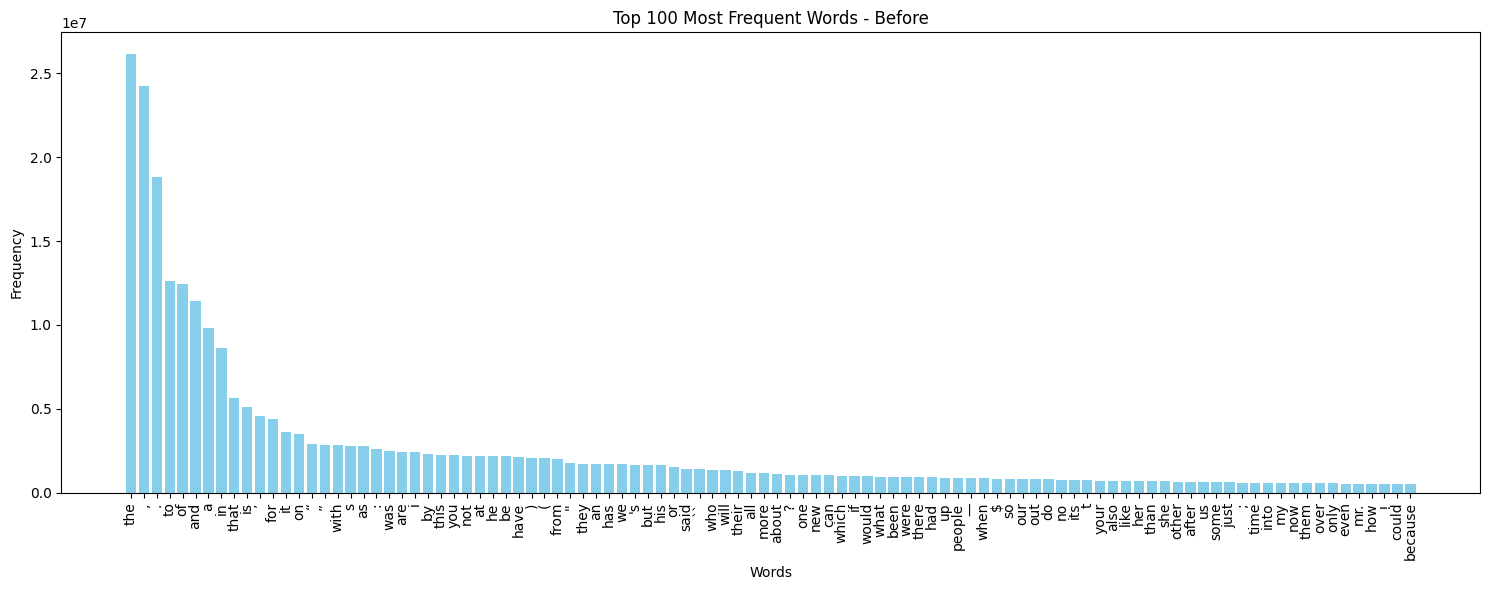

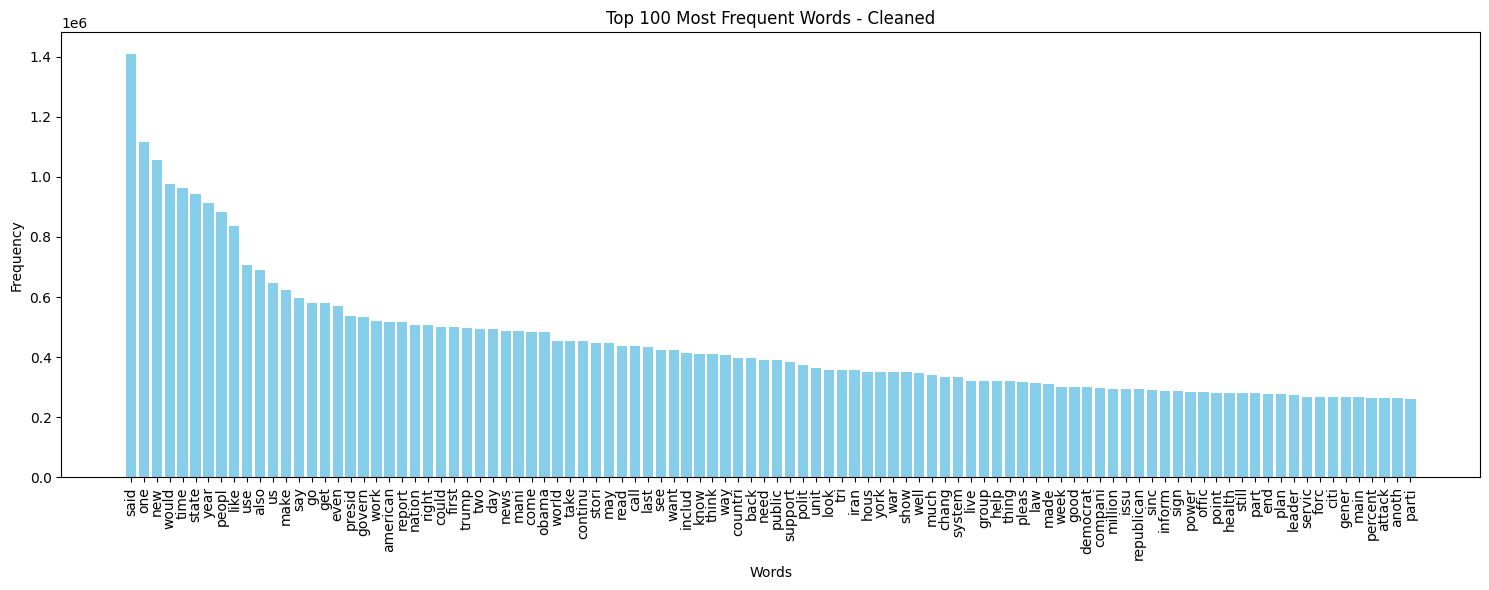

In [11]:
import matplotlib.pyplot as plt

summary = {
    "n_rows": stats["n_rows"],
    "n_missing_content": stats["n_missing_content"],
    "total_tokens_before": stats["total_tokens_before"],
    "total_tokens_after_stopwords": stats["total_tokens_after_stopwords"],
    "vocab_size_before": len(stats["unique_tokens_before"]),
    "vocab_size_after_stopwords": len(stats["unique_tokens_after_stopwords"]),
    "vocab_size_after_stemming": len(stats["unique_tokens_after_stemming"]),
    "reduction_rate_stopwords": 1 - (
        len(stats["unique_tokens_after_stopwords"]) / len(stats["unique_tokens_before"])
        if len(stats["unique_tokens_before"]) > 0 else 1
    ),
    "reduction_rate_stemming": 1 - (
        len(stats["unique_tokens_after_stemming"]) / len(stats["unique_tokens_after_stopwords"])
        if len(stats["unique_tokens_after_stopwords"]) > 0 else 1
    ),
    "top_100_before": stats["top_words_before"].most_common(100),
    "top_100_after_stopwords": stats["top_words_after_stopwords"].most_common(100),
    "top_100_after_stemming": stats["top_words_after_stemming"].most_common(100),
    "chunk_files": chunk_files,
}

with open("task2_summary.pkl", "wb") as f:
    pickle.dump(summary, f)

with open("task2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("rows processed:", summary["n_rows"])
print("vocabulary before:", summary["vocab_size_before"])
print("vocabulary after stopwords:", summary["vocab_size_after_stopwords"])
print("vocabulary after stemming:", summary["vocab_size_after_stemming"])
print("Saved chunks:", len(chunk_files))

words_default = [w for w, c in summary["top_100_before"]]
counts_default = [c for w, c in summary["top_100_before"]]

words_cleaned = [w for w, c in summary["top_100_after_stemming"]]
counts_cleaned = [c for w, c in summary["top_100_after_stemming"]]



# Plot the bar chart of before
plt.figure(figsize=(15, 6))  
plt.bar( words_default, counts_default, color='skyblue')
plt.xticks(rotation=90)      
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 100 Most Frequent Words - Before')
plt.tight_layout()
plt.show()

# Plot the bar chart of after
plt.figure(figsize=(15, 6))  
plt.bar(words_cleaned, counts_cleaned, color='skyblue')
plt.xticks(rotation=90)      
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Top 100 Most Frequent Words - Cleaned')
plt.tight_layout()
plt.show()


In [12]:
#Tjek en chunk
df1 = pd.read_parquet("processed_chunks_paquet/chunk_000.parquet")
print(df1.head())

   Unnamed: 0         id               domain        type  \
0         732  7444726.0   nationalreview.com   political   
1        1348  6213642.0    beforeitsnews.com        fake   
2        7119  3867639.0     dailycurrant.com      satire   
3        1518  9560791.0          nytimes.com    reliable   
4        9345  2059625.0  infiniteunknown.net  conspiracy   

                                                 url  \
0  http://www.nationalreview.com/node/152734/%E2%...   
1  http://beforeitsnews.com/economy/2012/06/the-c...   
2  http://dailycurrant.com/2016/01/18/man-awoken-...   
3  https://query.nytimes.com/gst/fullpage.html?re...   
4  http://www.infiniteunknown.net/2011/09/14/100-...   

                   scraped_at                 inserted_at  \
0  2017-11-27T01:14:42.983556  2018-02-08 19:18:34.468038   
1    2017-11-27T01:14:08.7454  2018-02-08 19:18:34.468038   
2  2017-11-27T01:14:21.395055  2018-02-07 23:39:33.852671   
3  2018-02-11 00:46:42.632962  2018-02-11 00:14:20.3

In [17]:
files = sorted(Path("processed_chunks_paquet").glob("chunk_*.parquet"))

for file in files[:3]:
    df = pd.read_parquet(file)
    
    print(file.name)
    print(df.head())

chunk_000.parquet
   Unnamed: 0         id               domain        type  \
0         732  7444726.0   nationalreview.com   political   
1        1348  6213642.0    beforeitsnews.com        fake   
2        7119  3867639.0     dailycurrant.com      satire   
3        1518  9560791.0          nytimes.com    reliable   
4        9345  2059625.0  infiniteunknown.net  conspiracy   

                                                 url  \
0  http://www.nationalreview.com/node/152734/%E2%...   
1  http://beforeitsnews.com/economy/2012/06/the-c...   
2  http://dailycurrant.com/2016/01/18/man-awoken-...   
3  https://query.nytimes.com/gst/fullpage.html?re...   
4  http://www.infiniteunknown.net/2011/09/14/100-...   

                   scraped_at                 inserted_at  \
0  2017-11-27T01:14:42.983556  2018-02-08 19:18:34.468038   
1    2017-11-27T01:14:08.7454  2018-02-08 19:18:34.468038   
2  2017-11-27T01:14:21.395055  2018-02-07 23:39:33.852671   
3  2018-02-11 00:46:42.632962  201

# Data Exploration:

100%|██████████| 100/100 [00:00<00:00, 302.32it/s]


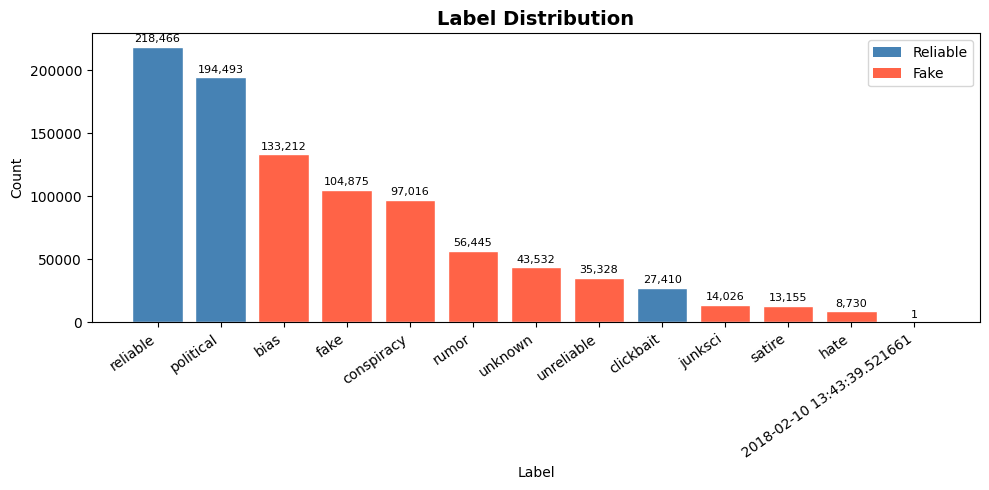

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import Counter

files = sorted(Path("processed_chunks_paquet").glob("chunk_*.parquet"))

label_counts = Counter()
for file in tqdm(files):
    df = pd.read_parquet(file, columns=["type"])
    counts = df["type"].dropna().value_counts()
    label_counts.update(counts.to_dict())

# Sort by count descending
labels, counts = zip(*sorted(label_counts.items(), key=lambda x: x[1], reverse=True))

# Color mapping
reliable_labels = {"reliable", "political", "clickbait"}
colors = ["steelblue" if label in reliable_labels else "tomato" for label in labels]

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, counts, color=colors, edgecolor="white")

ax.set_title("Label Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha="right")

# Add count annotations on top of each bar
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(counts) * 0.01,
            f"{count:,}", ha="center", va="bottom", fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="steelblue", label="Reliable"),
                   Patch(facecolor="tomato", label="Fake")]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig("label_distribution.png", dpi=150)
plt.show()

files[:60]
files[60:80]
files[80:100]

In [19]:
# Check for duplicate URLs and missing counts
total_rows = 0
missing_counts = pd.Series(dtype=float)
all_urls = []

for file in tqdm(files):
    df = pd.read_parquet(file)
    total_rows += len(df)
    if missing_counts is None:
        missing_counts = df.isnull().sum()
    else:
        missing_counts += df.isnull().sum()
    all_urls.extend(df["url"].tolist())

missing_pct = (missing_counts / total_rows * 100).round(2)
summary = pd.DataFrame({
    "missing_count": missing_counts,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

print(f"Total rows: {total_rows}\n")
print(summary)

# Duplicate URL report
url_series = pd.Series(all_urls)
n_dupes = url_series.duplicated().sum()
print(f"\nTotal URLs: {len(url_series)}")
print(f"Duplicate URLs: {n_dupes} ({n_dupes / len(url_series) * 100:.2f}%)")
print(f"Unique URLs: {url_series.nunique()}")


  0%|          | 0/100 [00:00<?, ?it/s]

Total rows: 994089

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Total URLs: 994089
Duplicate URLs: 0 (0.00%)
Unique URLs: 994089


In [20]:
## 3 More data exploration

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm

# Load a sample of processed parquet chunks
files = sorted(Path("processed_chunks_paquet").glob("chunk_*.parquet"))

dfs = []
for file in tqdm(files[:20]):   # start small; increase later if it works
    temp = pd.read_parquet(file)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

print("Columns in processed data:")
print(df.columns.tolist())
print()
print(df.head())

  0%|          | 0/20 [00:00<?, ?it/s]

Columns in processed data:
['Unnamed: 0', 'id', 'domain', 'type', 'url', 'scraped_at', 'inserted_at', 'updated_at', 'title', 'authors', 'keywords', 'meta_keywords', 'meta_description', 'tags', 'summary', 'source', 'tokens_stemmed']

  Unnamed: 0         id               domain        type  \
0        732  7444726.0   nationalreview.com   political   
1       1348  6213642.0    beforeitsnews.com        fake   
2       7119  3867639.0     dailycurrant.com      satire   
3       1518  9560791.0          nytimes.com    reliable   
4       9345  2059625.0  infiniteunknown.net  conspiracy   

                                                 url  \
0  http://www.nationalreview.com/node/152734/%E2%...   
1  http://beforeitsnews.com/economy/2012/06/the-c...   
2  http://dailycurrant.com/2016/01/18/man-awoken-...   
3  https://query.nytimes.com/gst/fullpage.html?re...   
4  http://www.infiniteunknown.net/2011/09/14/100-...   

                   scraped_at                 inserted_at  \
0  2017-

Using text column: tokens_stemmed
count    199959.000000
mean        209.613816
std         201.164276
min           1.000000
25%          50.000000
50%         155.000000
75%         305.000000
max        1000.000000
Name: n_tokens, dtype: float64


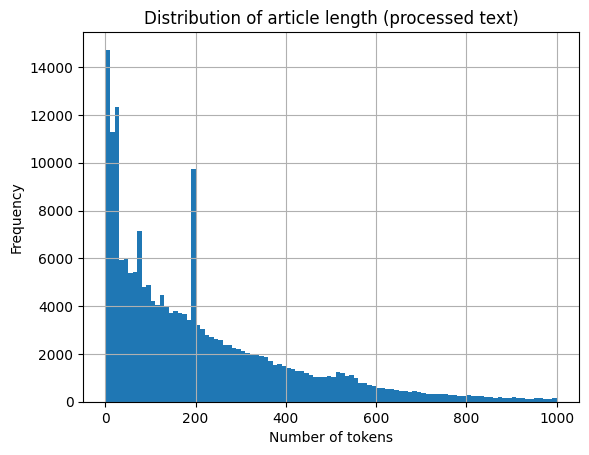

            n_tokens  date_count  num_count  url_count      non_ascii
count  199959.000000    199959.0   199959.0   199959.0  199959.000000
mean      209.613816         0.0        0.0        0.0      21.746133
std       201.164276         0.0        0.0        0.0     251.538606
min         1.000000         0.0        0.0        0.0       0.000000
25%        50.000000         0.0        0.0        0.0       0.000000
50%       155.000000         0.0        0.0        0.0       0.000000
75%       305.000000         0.0        0.0        0.0       0.000000
max      1000.000000         0.0        0.0        0.0    6760.000000


In [ ]:
# Find the text-like column that actually exists
if "clean_text" in df.columns:
    text_col = "clean_text"
elif "tokens_stemmed" in df.columns:
    text_col = "tokens_stemmed"
elif "tokens_clean" in df.columns:
    text_col = "tokens_clean"
else:
    raise ValueError(f"No usable processed text column found. Available columns: {df.columns.tolist()}")

print("Using text column:", text_col)

# If tokens are stored as lists, turn them into text for counting
if text_col in ["tokens_stemmed", "tokens_clean"]:
    df["processed_text"] = df[text_col].apply(
        lambda x: " ".join(x) if isinstance(x, list) else str(x)
    )
else:
    df["processed_text"] = df[text_col].astype(str)

# Length statistics
df["n_chars"] = df["processed_text"].str.len()
df["n_tokens"] = df["processed_text"].str.split().str.len()

print(df["n_tokens"].describe())

df["n_tokens"].hist(bins=100)
plt.title("Distribution of article length (processed text)")
plt.xlabel("Number of tokens")
plt.ylabel("Frequency")
plt.show()

# Dates
df["date_count"] = df["processed_text"].str.count(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b")

# Numeric values
df["num_count"] = df["processed_text"].str.count(r"\d+")

# URLs
df["url_count"] = df["processed_text"].str.count(r"http[s]?://")

# Non-ASCII characters
df["non_ascii"] = df["processed_text"].apply(
    lambda x: sum(ord(c) > 127 for c in str(x))
)

print(df[["n_tokens", "date_count", "num_count", "url_count", "non_ascii"]].describe())